# 03 · Cross-Country Comparisons

Rankings by spending priority and unsupervised **clustering** of countries by their average budget profile, visualised with PCA.

In [1]:
import sys
from pathlib import Path
# Locate the project root (the folder containing src/globalbudget) and add src to path.
_p = Path.cwd()
while _p != _p.parent and not (_p / "src" / "globalbudget").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from globalbudget import data_loader, cleaning, features, viz, forecasting
viz.set_theme()
pd.set_option("display.max_columns", 40)
print("Project root:", _p)


Project root: /Users/shrutichougule/Documents/global budget


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
wide = data_loader.load_master()

## 1. Rankings by priority (latest year)
Who spends the largest *share* on each function.

In [3]:
latest = wide.sort_values('Year').groupby('Country').tail(1).set_index('Country')
for cat in ['Defense','Education','Health','Social_Welfare']:
    col = f'{cat}_Percentage'
    print(f'\nTop 5 by {cat} share:')
    print(latest[col].sort_values(ascending=False).head(5).round(2).to_string())


Top 5 by Defense share:
Country
Saudi Arabia            22.31
Singapore               20.13
Israel                  19.99
Russia                  18.90
United Arab Emirates    17.04

Top 5 by Education share:
Country
Kazakhstan      21.96
Peru            19.21
South Africa    19.14
Iran            18.82
Chile           18.38

Top 5 by Health share:
Country
Japan        23.30
USA          23.02
Ireland      22.16
Australia    21.01
UK           20.05

Top 5 by Social_Welfare share:
Country
France         27.05
Italy          26.87
Greece         24.91
Switzerland    24.39
Netherlands    23.29


## 2. Spending-profile matrix
Each country's mean share across categories (the fingerprint we cluster on).

In [4]:
profiles = features.spending_profile_matrix(wide)  # country x category (mean %)
profiles.round(1).head()

,Defense,Education,Health,Interest_Payments,Infrastructure,Agriculture,State_Transfers,Social_Welfare,Administration_and_Others
Country,,,,,,,,,
Argentina,4.6,15.0,17.3,10.0,13.3,7.9,10.6,10.6,10.6
Australia,6.3,12.9,15.5,5.0,9.0,6.0,12.1,21.1,12.1
Bangladesh,10.2,9.9,4.7,19.2,16.8,8.4,8.4,8.4,14.0
Brazil,15.0,5.0,5.0,5.0,21.0,10.5,10.5,10.5,17.5
Canada,15.0,5.0,15.8,5.0,8.9,5.9,11.8,20.7,11.8


## 3. KMeans clustering
Standardise profiles, pick k by silhouette, then label clusters.

In [5]:
X = StandardScaler().fit_transform(profiles.values)
scores = {k: silhouette_score(X, KMeans(k, n_init=10, random_state=0).fit_predict(X)) for k in range(2,7)}
best_k = max(scores, key=scores.get)
print('silhouette by k:', {k: round(v,3) for k,v in scores.items()})
print('chosen k =', best_k)
km = KMeans(best_k, n_init=10, random_state=0).fit(X)
profiles['cluster'] = km.labels_

silhouette by k: {2: 0.266, 3: 0.269, 4: 0.315, 5: 0.288, 6: 0.305}
chosen k = 4


## 4. PCA projection of clusters

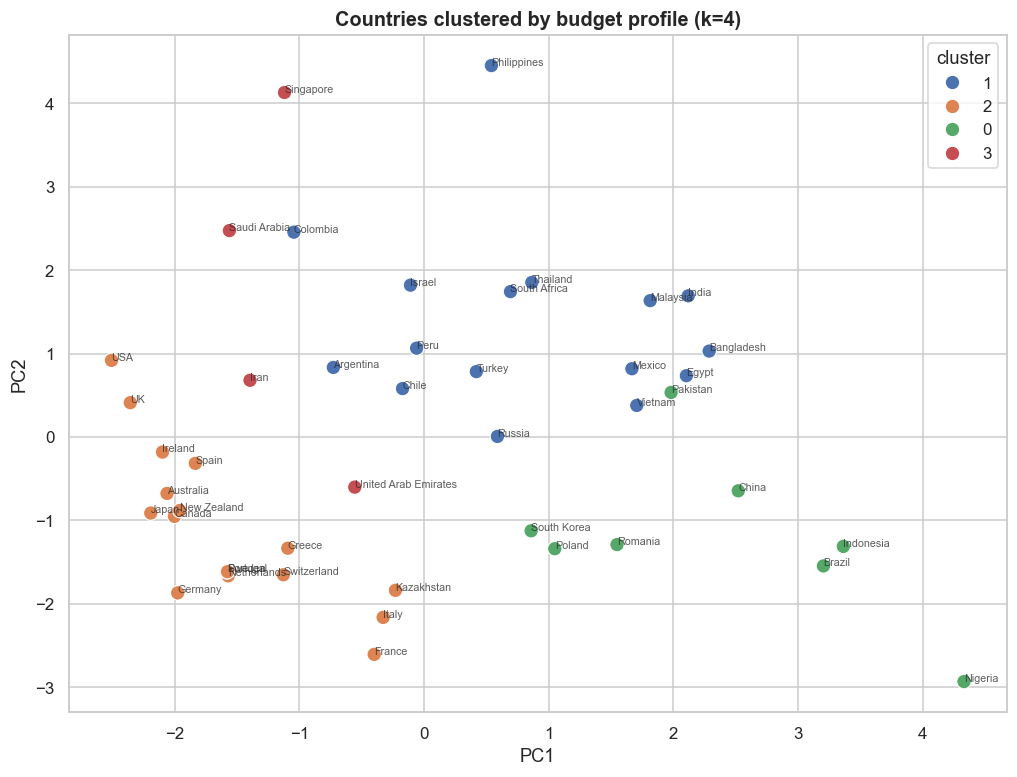

In [6]:
pcs = PCA(n_components=2, random_state=0).fit_transform(X)
fig, ax = plt.subplots(figsize=(11,8))
sns.scatterplot(x=pcs[:,0], y=pcs[:,1], hue=profiles['cluster'].astype(str), s=90, palette='deep', ax=ax)
for i, name in enumerate(profiles.index):
    ax.annotate(name, (pcs[i,0], pcs[i,1]), fontsize=7, alpha=0.75)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title(f'Countries clustered by budget profile (k={best_k})')
ax.legend(title='cluster')
viz.save(fig, 'cross_country_clusters'); plt.show()

## 5. What defines each cluster?
Mean profile per cluster highlights the distinguishing priorities.

In [7]:
cat_cols = [c for c in profiles.columns if c != 'cluster']
cluster_means = profiles.groupby('cluster')[cat_cols].mean().round(1)
display(cluster_means)
for cl in sorted(profiles.cluster.unique()):
    members = profiles.index[profiles.cluster==cl].tolist()
    print(f'Cluster {cl} ({len(members)}): ' + ', '.join(members))

,Defense,Education,Health,Interest_Payments,Infrastructure,Agriculture,State_Transfers,Social_Welfare,Administration_and_Others
cluster,,,,,,,,,
0,11.1,9.3,6.1,5.2,19.2,10.2,11.5,11.5,15.8
1,9.2,15.1,9.6,13.2,14.7,7.9,9.1,9.1,12.1
2,6.2,11.2,13.1,6.4,9.9,6.1,12.8,21.5,12.8
3,23.3,17.2,9.9,3.1,11.6,3.2,11.2,9.3,11.2


Cluster 0 (8): Brazil, China, Indonesia, Nigeria, Pakistan, Poland, Romania, South Korea
Cluster 1 (16): Argentina, Bangladesh, Chile, Colombia, Egypt, India, Israel, Malaysia, Mexico, Peru, Philippines, Russia, South Africa, Thailand, Turkey, Vietnam
Cluster 2 (17): Australia, Canada, France, Germany, Greece, Ireland, Italy, Japan, Kazakhstan, Netherlands, New Zealand, Portugal, Spain, Sweden, Switzerland, UK, USA
Cluster 3 (4): Iran, Saudi Arabia, Singapore, United Arab Emirates


Clusters separate broadly into defense-heavy, social-welfare-heavy, and development/infrastructure-oriented spending regimes. Next: **04_time_series_forecasting**.